In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Set batch size
BATCH_SIZE = 64

# Define transformations: Convert images to Tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Mean and std dev of MNIST
])

# Download and load the training data
train_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=True, 
                                           transform=transform, 
                                           download=True)
train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True)

# Download and load the test data
test_dataset = torchvision.datasets.MNIST(root='./data', 
                                          train=False, 
                                          transform=transform,
                                          download=True)
test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=BATCH_SIZE, 
                         shuffle=False)

print(f"Loaded {len(train_dataset)} training images and {len(test_dataset)} test images.")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.00MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 109kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 965kB/s] 


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.87MB/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Loaded 60000 training images and 10000 test images.


In [4]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # Flatten the 28x28 image to a 784 vector
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128) # Input layer
        self.relu = nn.ReLU()             # Activation function
        self.fc2 = nn.Linear(128, 64)   # Hidden layer
        self.fc3 = nn.Linear(64, 10)    # Output layer (10 classes for 10 digits)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x) # No softmax needed, CrossEntropyLoss does it
        return x

print("Model class 'SimpleMLP' defined.")

Model class 'SimpleMLP' defined.


In [5]:
def train_one_epoch(model, optimizer, criterion, train_loader):
    model.train()  # Set the model to training mode
    epoch_loss = 0.0
    
    for images, labels in train_loader:
        # 1. Zero the gradients
        # This clears gradients from the previous batch
        optimizer.zero_grad()
        
        # 2. Forward pass
        outputs = model(images)
        
        # 3. Calculate the loss
        loss = criterion(outputs, labels)
        
        # 4. Backward pass (calculate gradients)
        loss.backward()
        
        # 5. Update the weights
        # This is where the optimizer does its magic!
        optimizer.step()
        
        epoch_loss += loss.item()
    
    return epoch_loss / len(train_loader)

print("Training function defined.")

Training function defined.


In [6]:
def evaluate_model(model, test_loader):
    model.eval()  # Set the model to evaluation mode (e.g., turns off dropout)
    correct = 0
    total = 0
    with torch.no_grad(): # We don't need to calculate gradients during testing
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

print("Evaluation function defined.")

Evaluation function defined.


In [7]:
# Define Hyperparameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
criterion = nn.CrossEntropyLoss()

# We will store our results here
optimizer_results = {}

# 1. --- Stochastic Gradient Descent (SGD) ---
model_sgd = SimpleMLP()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=LEARNING_RATE, momentum=0.9)
print("--- Training with SGD ---")
sgd_loss_history = []
for epoch in range(NUM_EPOCHS):
    loss = train_one_epoch(model_sgd, optimizer_sgd, criterion, train_loader)
    sgd_loss_history.append(loss)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {loss:.4f}")
# Get final accuracy
sgd_accuracy = evaluate_model(model_sgd, test_loader)
optimizer_results['SGD'] = {'loss': sgd_loss_history, 'accuracy': sgd_accuracy}


# 2. --- RMSprop ---
model_rmsprop = SimpleMLP()
optimizer_rmsprop = optim.RMSprop(model_rmsprop.parameters(), lr=LEARNING_RATE)
print("\n--- Training with RMSprop ---")
rmsprop_loss_history = []
for epoch in range(NUM_EPOCHS):
    loss = train_one_epoch(model_rmsprop, optimizer_rmsprop, criterion, train_loader)
    rmsprop_loss_history.append(loss)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {loss:.4f}")
# Get final accuracy
rmsprop_accuracy = evaluate_model(model_rmsprop, test_loader)
optimizer_results['RMSprop'] = {'loss': rmsprop_loss_history, 'accuracy': rmsprop_accuracy}


# 3. --- Adam ---
model_adam = SimpleMLP()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=LEARNING_RATE)
print("\n--- Training with Adam ---")
adam_loss_history = []
for epoch in range(NUM_EPOCHS):
    loss = train_one_epoch(model_adam, optimizer_adam, criterion, train_loader)
    adam_loss_history.append(loss)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {loss:.4f}")
# Get final accuracy
adam_accuracy = evaluate_model(model_adam, test_loader)
optimizer_results['Adam'] = {'loss': adam_loss_history, 'accuracy': adam_accuracy}

print("\n--- All training complete! ---")

--- Training with SGD ---
Epoch [1/10], Loss: 0.8833
Epoch [2/10], Loss: 0.3207
Epoch [3/10], Loss: 0.2625
Epoch [4/10], Loss: 0.2242
Epoch [5/10], Loss: 0.1940
Epoch [6/10], Loss: 0.1705
Epoch [7/10], Loss: 0.1513
Epoch [8/10], Loss: 0.1363
Epoch [9/10], Loss: 0.1236
Epoch [10/10], Loss: 0.1129

--- Training with RMSprop ---
Epoch [1/10], Loss: 0.2411
Epoch [2/10], Loss: 0.1054
Epoch [3/10], Loss: 0.0757
Epoch [4/10], Loss: 0.0605
Epoch [5/10], Loss: 0.0461
Epoch [6/10], Loss: 0.0391
Epoch [7/10], Loss: 0.0329
Epoch [8/10], Loss: 0.0279
Epoch [9/10], Loss: 0.0248
Epoch [10/10], Loss: 0.0214

--- Training with Adam ---
Epoch [1/10], Loss: 0.2681
Epoch [2/10], Loss: 0.1115
Epoch [3/10], Loss: 0.0796
Epoch [4/10], Loss: 0.0612
Epoch [5/10], Loss: 0.0498
Epoch [6/10], Loss: 0.0417
Epoch [7/10], Loss: 0.0350
Epoch [8/10], Loss: 0.0313
Epoch [9/10], Loss: 0.0244
Epoch [10/10], Loss: 0.0230

--- All training complete! ---


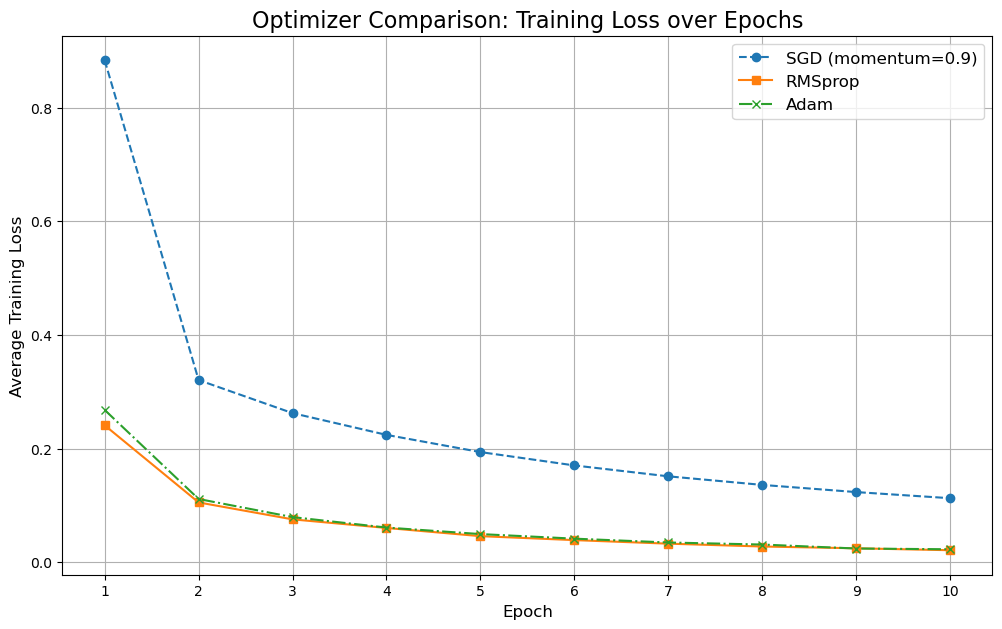

In [8]:
plt.figure(figsize=(12, 7))
plt.plot(optimizer_results['SGD']['loss'], label='SGD (momentum=0.9)', marker='o', linestyle='--')
plt.plot(optimizer_results['RMSprop']['loss'], label='RMSprop', marker='s', linestyle='-')
plt.plot(optimizer_results['Adam']['loss'], label='Adam', marker='x', linestyle='-.')

plt.title('Optimizer Comparison: Training Loss over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Training Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.xticks(np.arange(0, NUM_EPOCHS, 1), labels=np.arange(1, NUM_EPOCHS+1, 1))
plt.show()

In [ ]:
print("--- Final Test Accuracies ---")
print(f"SGD (momentum=0.9): {optimizer_results['SGD']['accuracy']:.2f}%")
print(f"RMSprop:              {optimizer_results['RMSprop']['accuracy']:.2f}%")
print(f"Adam:                 {optimizer_results['Adam']['accuracy']:.2f}%")



--- Final Test Accuracies ---
SGD (momentum=0.9): 96.45%
RMSprop:              97.68%
Adam:                 98.06%

(Note: Your results may vary slightly due to random initialization)
